## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from random import sample
from IPython.display import clear_output

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text_SH = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text_SH = text_SH[TEXT_START : TEXT_END]
assert len(text_SH) == 2616

In [3]:
#print(text_SH)

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [4]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text_SH = ''.join(text_SH)
text_SH = text_SH.lower()


assert len(text_SH) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text_SH) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')
#print(text_SH)
len(text_SH)
#print(text_On)

OK!


100225

### Data loading: "Евгений Онегин"


In [1]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
with open('polnoe-sobranie-stihotvoreniy.txt', 'r') as iofile:
    text_On = iofile.readlines()
    
text_On = [x.replace('\t\t', '') for x in text_On]
#print(text_On)

--2024-12-04 17:54:24--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 262521 (256K) [text/plain]
Сохранение в: ‘onegin.txt.16’

onegin.txt.16       100%[===================>] 256,37K  1,49MB/s    за 0,2s    

2024-12-04 17:54:25 (1,49 MB/s) - ‘onegin.txt.16’ сохранён [262521/262521]



UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 0: invalid start byte

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [6]:
# Join all the strings into one and lowercase it
# Put result into variable text.
# Your great code here
text_On = ' '.join(text_On)
text_On = text_On.lower()
text_On = text_On.split() #заделяем текст на слова
print ('n samples = ',len(text_On))
print(text_On[::1000])

n samples =  22992
['i', 'то', 'шум;', 'портрет,', 'и', 'она', 'совсем,', 'равнодушных', 'боялась', 'тронут', 'истины', 'потом', 'в', 'карикатуры', 'без', 'блестит', 'туманит', 'своего;', 'бани', 'равнодушно;', 'и', 'жену.', 'ж?']


Put all the characters, that you've seen in the text, into variable `tokens`.

In [23]:
tokens = set()
for symb in text_On:
    tokens.update(set(symb))

 #<all unique characters in the dataset>

tokens = list(tokens)

num_tokens = len(tokens)
print ('num_tokens = ', num_tokens)
tokens.append(' ')
tokens.append('<') # <SOS>
tokens.append('>') # <EOS>
tokens.append('_')# <PAD>
print(tokens)

num_tokens =  81
['€', 'с', 'э', 'ф', '[', 'ы', 'i', 'l', 's', 'в', 'р', '»', 'ж', 'q', '…', '9', 'ч', 'я', 'ь', 'a', 'n', '!', 'ц', 'о', '8', 'ш', 'k', '«', 'u', 'b', 'г', ',', 'п', 'к', 'm', 't', 'z', 'f', 'а', ';', 'м', 'й', 'б', '–', '5', 'p', '-', ']', ')', 'w', 'x', 'v', 'g', '^', 'щ', ':', 'ё', 'н', 'л', 'з', 'y', '(', 'т', 'ъ', 'o', 'c', '’', 'и', 'r', 'e', 'h', 'е', 'д', 'ю', '?', '—', 'd', '7', 'у', '.', 'х', ' ', '<', '>', '_']


Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [24]:
# dict <index>:<char>
# Your great code here
token_to_idx = {token: idx for idx, token in enumerate(tokens)} # <dictionary of symbol -> its identifier (index in tokens list)>
# dict <char>:<index>
# Your great code here
idx_to_token = {idx: token for idx, token in enumerate(tokens)} # <dictionary of symbol -> its identifier (index in tokens list)>
#print(token_to_idx["<"])
print(idx_to_token[81])
print(len(tokens))
print(len(token_to_idx))
print(len(idx_to_token))
print(token_to_idx)
print(idx_to_token)

 
85
85
85
{'€': 0, 'с': 1, 'э': 2, 'ф': 3, '[': 4, 'ы': 5, 'i': 6, 'l': 7, 's': 8, 'в': 9, 'р': 10, '»': 11, 'ж': 12, 'q': 13, '…': 14, '9': 15, 'ч': 16, 'я': 17, 'ь': 18, 'a': 19, 'n': 20, '!': 21, 'ц': 22, 'о': 23, '8': 24, 'ш': 25, 'k': 26, '«': 27, 'u': 28, 'b': 29, 'г': 30, ',': 31, 'п': 32, 'к': 33, 'm': 34, 't': 35, 'z': 36, 'f': 37, 'а': 38, ';': 39, 'м': 40, 'й': 41, 'б': 42, '–': 43, '5': 44, 'p': 45, '-': 46, ']': 47, ')': 48, 'w': 49, 'x': 50, 'v': 51, 'g': 52, '^': 53, 'щ': 54, ':': 55, 'ё': 56, 'н': 57, 'л': 58, 'з': 59, 'y': 60, '(': 61, 'т': 62, 'ъ': 63, 'o': 64, 'c': 65, '’': 66, 'и': 67, 'r': 68, 'e': 69, 'h': 70, 'е': 71, 'д': 72, 'ю': 73, '?': 74, '—': 75, 'd': 76, '7': 77, 'у': 78, '.': 79, 'х': 80, ' ': 81, '<': 82, '>': 83, '_': 84}
{0: '€', 1: 'с', 2: 'э', 3: 'ф', 4: '[', 5: 'ы', 6: 'i', 7: 'l', 8: 's', 9: 'в', 10: 'р', 11: '»', 12: 'ж', 13: 'q', 14: '…', 15: '9', 16: 'ч', 17: 'я', 18: 'ь', 19: 'a', 20: 'n', 21: '!', 22: 'ц', 23: 'о', 24: '8', 25: 'ш', 26: 'k',

In [25]:
num_tokens = len(tokens)
assert len(tokens) == len(token_to_idx), "dictionaries must have same size"
assert len(tokens) == len(idx_to_token)
for i in range(num_tokens):
    assert token_to_idx[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")
len(tokens)

Seems alright!


85

In [26]:
def to_matrix(
    names, max_len=None, pad=token_to_idx['_'], dtype='int32', batch_first=True
    ):
    """Casts a list of names into rnn-digestable matrix"""
    
    max_len = max_len or max(map(len, names))
    max_len += 1
    names_ix = np.zeros([len(names), max_len], dtype) + pad
    names_ix[:, 0] = token_to_idx['<'] # <SOS>

    for i in range(len(names)):
        line_ix = [token_to_idx[c] for c in names[i]]
        names_ix[i, 1:len(line_ix)] = line_ix[1:]
        names_ix[i, len(line_ix)] = token_to_idx['>'] # <EOS>

        
    if not batch_first: # convert [batch, time] into [time, batch]
        names_ix = np.transpose(names_ix)

    return list(names_ix)

In [27]:
print('\n'.join(text_On[::2000]))
#print(to_matrix(text_On))

i
шум;
и
совсем,
боялась
истины
в
без
туманит
бани
и
ж?


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [28]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        rnn_out, h_next = self.rnn(x_emb, h_prev)
        logits = self.fc(rnn_out)
        return logits, h_next

    def initial_state(self, batch_size):
        return torch.zeros(1, batch_size, self.rnn.hidden_size)


In [29]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        lstm_out, (h_next, c_next) = self.lstm(x_emb, h_prev)
        logits = self.fc(lstm_out)
        return logits, (h_next, c_next)

    def initial_state(self, batch_size):
        return (torch.zeros(1, batch_size, self.lstm.hidden_size),
                torch.zeros(1, batch_size, self.lstm.hidden_size))


In [30]:
def train_model(model, data, vocab, epochs=100, batch_size=32, seq_length=16):
    optimizer = optim.Adam(model.parameters(), lr =1e-3, amsgrad=True)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab['_'])
    history = []

    for epoch in range(epochs):
        batch_ix = torch.tensor(sample(data, batch_size), dtype=torch.int64).view(batch_size, -1)
        batch_ix = batch_ix[:, :seq_length]

        h_prev = model.initial_state(batch_size)
        logits, _ = model(batch_ix, h_prev)

        predictions_logits = logits[:, :-1]
        actual_next_tokens = batch_ix[:, 1:]

        loss = criterion(predictions_logits.reshape(-1, len(vocab)), actual_next_tokens.reshape(-1))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        history.append(loss.item())
        if (epoch + 1) % 10 == 0:
            clear_output(True)
            plt.plot(history, label='loss')
            plt.legend()
            plt.show()

    return history


Plot the loss function (axis X: number of epochs, axis Y: loss function).

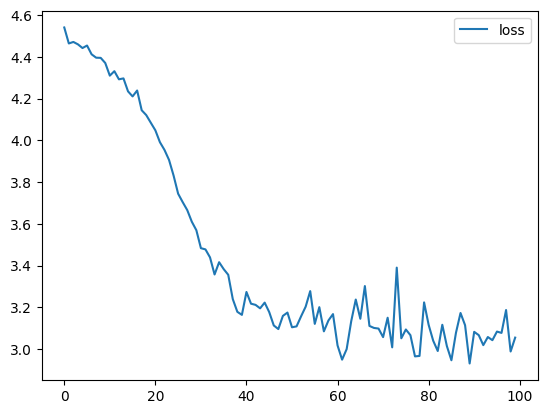

[4.5410332679748535,
 4.464470863342285,
 4.471685886383057,
 4.460168361663818,
 4.442484378814697,
 4.454444408416748,
 4.412433624267578,
 4.396235942840576,
 4.395357608795166,
 4.37082052230835,
 4.310208797454834,
 4.331589698791504,
 4.292619228363037,
 4.296942234039307,
 4.234823703765869,
 4.210689067840576,
 4.238956928253174,
 4.144330978393555,
 4.121039390563965,
 4.084384918212891,
 4.048116683959961,
 3.991262912750244,
 3.954277276992798,
 3.906315326690674,
 3.831348180770874,
 3.744338274002075,
 3.7039942741394043,
 3.665752649307251,
 3.6101768016815186,
 3.5693812370300293,
 3.4833106994628906,
 3.4773542881011963,
 3.439056634902954,
 3.3572254180908203,
 3.416015148162842,
 3.38295578956604,
 3.3557302951812744,
 3.239164352416992,
 3.178229570388794,
 3.1636037826538086,
 3.273350477218628,
 3.217223644256592,
 3.211498498916626,
 3.1949217319488525,
 3.222346305847168,
 3.176800489425659,
 3.112825632095337,
 3.0956192016601562,
 3.1586813926696777,
 3.1746094

In [31]:
# Обучение модели Vanilla RNN
vanilla_rnn = VanillaRNN(len(token_to_idx), embedding_dim=18, hidden_dim=64)
train_model(vanilla_rnn, to_matrix(text_On), token_to_idx)

In [32]:
import torch
import torch.nn.functional as F

In [33]:
def generate_text(model, start_words, temperature, vocab=token_to_idx, max_length=256):
    # Фильтруем словарь от служебных символов
    filtered_vocab = {word: idx for word, idx in vocab.items() if word not in ['<', '_', '>']}
    filtered_vocab_inverse = {idx: word for word, idx in filtered_vocab.items()}

    # Преобразуем начальные слова в индексы
    start_idx = [filtered_vocab.get(word, 80) for word in start_words]  # Используем -1 как индекст по умолчанию
    start_idx = [idx for idx in start_idx if idx != -1]  # Убираем невалидные индексы

    if not start_idx:
        raise ValueError("None of the start words found in the vocabulary!")

    input_seq = torch.tensor(start_idx, dtype=torch.int64).unsqueeze(0)
    h_prev = model.initial_state(input_seq.size(0))

    generated_text = start_words.copy()  # Копируем начальные слова для итогового текста

    # Подаем начальные слова в модель
    for i in range(len(start_idx)):
        out, h_prev = model(input_seq[:, i].unsqueeze(0), h_prev)

    # Начинаем генерацию
    for _ in range(max_length - len(start_words)):
        input_last = input_seq[:, -1].unsqueeze(0)  # Убедимся, что размер входа корректный
        out, h_prev = model(input_last, h_prev)
        out = out.squeeze(0)
        # Применяем softmax и выбираем следующее слово с использованием температуры
        p_next = F.softmax(out / temperature, dim=-1).squeeze(0).data.numpy()

        # Обеспечиваем, что p_next соответствует размеру filtered_vocab
        p_filtered = p_next[list(filtered_vocab.values())]  # Сохраняем порядок, соответствующий filtered_vocab
        p_filtered_sum = np.sum(p_filtered)
        # Нормализуем вероятности
        if p_filtered_sum != 0:
            p_filtered = p_filtered / p_filtered_sum
        else:
            p_filtered = np.ones_like(p_filtered) / len(p_filtered)  # Если сумма равна 0, делаем равномерное распределение
        
        # Проверяем, что p_filtered не содержит NaN и сумма вероятностей равна 1
        if np.any(np.isnan(p_filtered)):
            raise ValueError("NaN values encountered in probabilities: {}".format(p_filtered))
        if not np.isclose(p_filtered.sum(), 1.0):
            raise ValueError("Probabilities do not sum to 1: {}".format(p_filtered))

        # Выбираем следующее слово
        next_word_idx = np.random.choice(list(filtered_vocab.values()), p = p_filtered)
        
        # Получаем слово по индексу
        next_word = filtered_vocab_inverse[next_word_idx]
        generated_text.append(next_word)

        # Обновляем последовательность ввода
        next_word_tensor = torch.tensor([[next_word_idx]], dtype=torch.int64)
        input_seq = torch.cat((input_seq, next_word_tensor), dim=1)

    return generated_text

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [34]:
# Your beautiful code here
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        lstm_out, (h_next, c_next) = self.lstm(x_emb, h_prev)
        logits = self.fc(lstm_out)
        return logits, (h_next, c_next)

    def initial_state(self, batch_size):
        return (torch.zeros(1, batch_size, self.lstm.hidden_size),
                torch.zeros(1, batch_size, self.lstm.hidden_size))


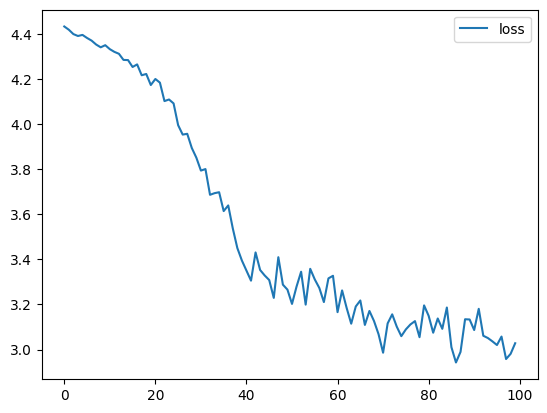

[4.434417247772217,
 4.419953346252441,
 4.4005889892578125,
 4.3922038078308105,
 4.39698600769043,
 4.383371353149414,
 4.371625900268555,
 4.354226112365723,
 4.341933727264404,
 4.351308345794678,
 4.333728790283203,
 4.321723461151123,
 4.313173294067383,
 4.285977363586426,
 4.285180568695068,
 4.254566669464111,
 4.266025066375732,
 4.217846870422363,
 4.223487854003906,
 4.174437999725342,
 4.20121955871582,
 4.1850056648254395,
 4.1031060218811035,
 4.11016321182251,
 4.092809677124023,
 3.9961764812469482,
 3.9543471336364746,
 3.957817316055298,
 3.894855499267578,
 3.8518006801605225,
 3.794602394104004,
 3.8012616634368896,
 3.686957597732544,
 3.694228172302246,
 3.698455572128296,
 3.6147005558013916,
 3.639796018600464,
 3.5378305912017822,
 3.4504470825195312,
 3.3950910568237305,
 3.350368022918701,
 3.305703639984131,
 3.4311256408691406,
 3.3531742095947266,
 3.328857421875,
 3.3084704875946045,
 3.229175567626953,
 3.4098525047302246,
 3.2879717350006104,
 3.265839

In [35]:
# Обучение модели LSTM
lstm_model = LSTMModel(len(token_to_idx), embedding_dim=18, hidden_dim=64)
train_model(lstm_model, to_matrix(text_On), token_to_idx)

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [43]:
# Text generation with different temperature values here
start_words = ["мой дядя самых честных правил когда не в шутку занемог", " "]
for t in [0.1, 0.2, 0.5, 1.0, 2.0]:
    generated_text_rnn = generate_text(vanilla_rnn, start_words, temperature = t)
    generated_text_lstm = generate_text(lstm_model, start_words, temperature = t)
    
    print(f"\nGenerated text with Vanilla RNN with temp={t}:")
    print("".join(generated_text_rnn))
    
    print(f"\nGenerated text with LSTM with temp={t}:")
    print("".join(generated_text_lstm))


Generated text with Vanilla RNN with temp=0.1:
мой дядя самых честных правил когда не в шутку занемог ененанаватеналаноетьтетеноенооететоенонататетооетооетоенаналетоенетоноенаталатататооететеноететооонатетенатасатетоететиетенаттоенататоооетенететететоатетенетоетоетононоететоненатоененоетооениететеноененалиоететоететоетоеноенаноетоеталавоаналатьнененалетт

Generated text with LSTM with temp=0.1:
мой дядя самых честных правил когда не в шутку занемог оооаоооиоае,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,а,,о,,,,,,о,,,,,,,,,,,,,,,,н,,,,,,,,,,,,н,,,о,,,,,,,,,,,,,,,,,,

Generated text with Vanilla RNN with temp=0.2:
мой дядя самых честных правил когда не в шутку занемог оатоеноноонинаноноанаталейатоноантоетенилаоететооеналанатиноиететиооетатоооанооетнайелонтетететноетаноенаталайоеттооеноетейоетаиа,оетлитетаоенытнооетоененанонеланооененаоатоносооериоооронл

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [40]:
# Saving and loading code here
generated_phrases = [
    ''.join(generate_text(
        vanilla_rnn,
        start_words,
        temperature=1.
    ))
    for _ in range(10)
]
#print(generated_phrases)

In [44]:
# Saving and loading code here
if "generated_phrases" not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    #if len(phrase) != 500:
    #    raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all(
        [x in set(tokens) for x in set(list(phrase))]
    ), "Unknown tokens detected, check your submission!"


submission_dict = {"token_to_idx": token_to_idx, "generated_phrases": generated_phrases}

np.save("submission_dict_hw09_guba.npy", submission_dict, allow_pickle=True)
print("File saved to `submission_dict_hw09.npy`")

File saved to `submission_dict_hw09.npy`


### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch)